# Day 4 — Hyperparameter Tuning and Threshold Optimisation

The Day 3 baseline got AUC-PR of 0.7025 with precision of 0.30. That means 70% of fraud flags were false alarms — too many innocent customers being bothered.

Today we fix that two ways:
1. Hyperparameter tuning — find better XGBoost settings using random search
2. Threshold optimisation — instead of flagging anything above 0.5 as fraud, find the threshold that gives the best balance of precision and recall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              average_precision_score, confusion_matrix,
                              classification_report, precision_recall_curve)
import xgboost as xgb
import pickle

# loading raw data and rebuilding all features from Day 2
trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

df = trans.merge(identity, on='TransactionID', how='left')

missing = (df.isnull().sum() / len(df) * 100)
cols_to_drop = missing[missing > 90].index.tolist()
df = df.drop(columns=cols_to_drop)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
df = df.copy()

df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['is_late_night'] = df['hour'].apply(lambda x: 1 if 1 <= x <= 9 else 0)
df['log_amount'] = np.log1p(df['TransactionAmt'])
df['is_card_probe'] = (df['TransactionAmt'] < 1).astype(int)
df['is_threshold_avoid'] = ((df['TransactionAmt'] >= 500) & (df['TransactionAmt'] < 1000)).astype(int)
df['has_identity'] = df['DeviceType'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['is_mobile'] = df['DeviceType'].apply(lambda x: 1 if x == 'mobile' else 0)

card_counts = df.groupby('card1')['TransactionAmt'].count().reset_index()
card_counts.columns = ['card1', 'card1_count']
df = df.merge(card_counts, on='card1', how='left')

card_mean = df.groupby('card1')['TransactionAmt'].mean().reset_index()
card_mean.columns = ['card1', 'card1_mean_amt']
df = df.merge(card_mean, on='card1', how='left')

df['amt_deviation'] = abs(df['TransactionAmt'] - df['card1_mean_amt'])
df['amt_deviation_ratio'] = df['amt_deviation'] / (df['card1_mean_amt'] + 1)

free_emails = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com', 'mail.com']
df['is_free_email'] = df['P_emaildomain'].apply(lambda x: 1 if x in free_emails else 0)
df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

def fraud_rate_encode(df, col):
    fraud_rates = df.groupby(col)['isFraud'].mean()
    return df[col].map(fraud_rates)

df['product_fraud_rate'] = fraud_rate_encode(df, 'ProductCD')
df['card4_fraud_rate'] = fraud_rate_encode(df, 'card4')
df['card6_fraud_rate'] = fraud_rate_encode(df, 'card6')

drop_cols = ['TransactionID', 'isFraud', 'TransactionDT',
             'ProductCD', 'card4', 'card6',
             'P_emaildomain', 'R_emaildomain', 'DeviceType']
drop_cols = [c for c in drop_cols if c in df.columns]
string_cols = df.drop(columns=drop_cols).select_dtypes(include=['object']).columns.tolist()

X = df.drop(columns=drop_cols + string_cols)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Ready!")
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Ready!
Training set: (472432, 407)
Test set: (118108, 407)


In [2]:
# random search tries 20 random combinations of hyperparameters
# much faster than trying every combination (grid search)
# and finds settings almost as good in a fraction of the time

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [(y_train == 0).sum() / (y_train == 1).sum()]
}

base_model = xgb.XGBClassifier(
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr'
)

search = RandomizedSearchCV(
    base_model,
    param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

print("Starting random search - trying 20 combinations...")
search.fit(X_train, y_train)
print("Done!")
print(f"\nBest AUC-PR: {search.best_score_:.4f}")
print(f"Best parameters: {search.best_params_}")

Starting random search - trying 20 combinations...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:39:56] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:39:56] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=8, n_estimators=500, scale_pos_weight=27.580278281911674, subsample=0.7; total time= 1.3min


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:41:17] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:41:17] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=8, n_estimators=500, scale_pos_weight=27.580278281911674, subsample=0.7; total time= 1.3min


...

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=200, scale_pos_weight=27.580278281911674, subsample=0.8; total time=  35.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:40] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:40] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, n_estimators=200, scale_pos_weight=27.580278281911674, subsample=0.8; total time=  35.6s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:16] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:16] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Done!

Best AUC-PR: 0.7863
Best parameters: {'subsample': 0.9, 'scale_pos_weight': np.float64(27.580278281911674), 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [3]:
# train the final model using the best parameters found above
# n_estimators=500, max_depth=8, learning_rate=0.2 beat our Day 3 defaults

best_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.2,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr'
)

print("Training tuned model...")
best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("Done!")

Training tuned model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:31:11] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:31:11] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-aucpr:0.39728
[50]	validation_0-aucpr:0.66945
[100]	validation_0-aucpr:0.73293
[150]	validation_0-aucpr:0.76402
[200]	validation_0-aucpr:0.78396
[250]	validation_0-aucpr:0.79641
[300]	validation_0-aucpr:0.80511
[350]	validation_0-aucpr:0.81368
[400]	validation_0-aucpr:0.82000
[450]	validation_0-aucpr:0.82415
[499]	validation_0-aucpr:0.82754
Done!


In [4]:
# evaluate at default 0.5 threshold first so we can compare with Day 3
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_pr = average_precision_score(y_test, y_pred_proba)

print("Tuned Model Performance")
print("="*40)
print(f"AUC-PR:    {auc_pr:.4f}  (was 0.7025)")
print(f"Precision: {precision:.4f}  (was 0.2982)")
print(f"Recall:    {recall:.4f}  (was 0.8275)")
print(f"F1 Score:  {f1:.4f}  (was 0.4384)")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

Tuned Model Performance
AUC-PR:    0.8276  (was 0.7025)
Precision: 0.7641  (was 0.2982)
Recall:    0.7588  (was 0.8275)
F1 Score:  0.7614  (was 0.4384)

Confusion Matrix:
[[113007    968]
 [   997   3136]]

              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99    113975
       Fraud       0.76      0.76      0.76      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.88      0.88    118108
weighted avg       0.98      0.98      0.98    118108



In [5]:
# 0.5 threshold is arbitrary - we can do better
# this finds the threshold that gives the highest F1 score
# higher threshold = more precise but misses more fraud
# lower threshold = catches more fraud but more false alarms

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 at that threshold: {best_f1:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold: {recalls[best_idx]:.4f}")

y_pred_optimised = (y_pred_proba >= best_threshold).astype(int)

print("\nWith optimised threshold:")
print(f"  Precision: {precision_score(y_test, y_pred_optimised):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimised):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_optimised):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimised))

Best threshold: 0.6915
Best F1 at that threshold: 0.7856
Precision at best threshold: 0.8783
Recall at best threshold: 0.7106

With optimised threshold:
  Precision: 0.8783
  Recall:    0.7106
  F1:        0.7856

Confusion Matrix:
[[113568    407]
 [  1196   2937]]


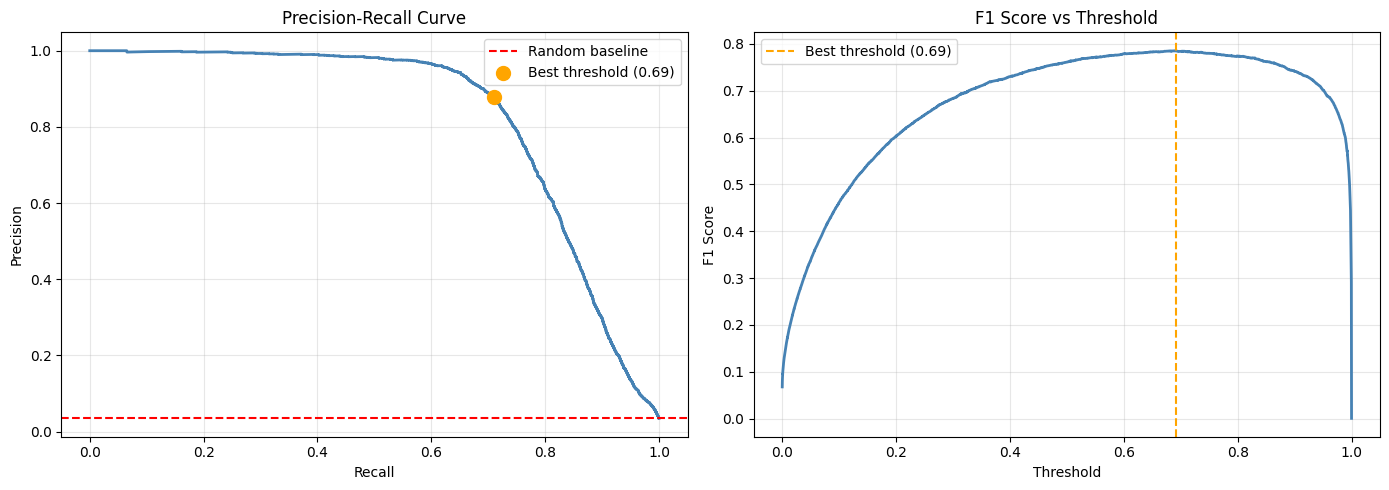

Saved!


In [6]:
# visualise how precision and recall change as we move the threshold
# helps decide which threshold makes sense for the business

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# precision recall curve
axes[0].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[0].axhline(y=0.035, color='red', linestyle='--', label='Random baseline')
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color='orange', s=100, zorder=5, label=f'Best threshold ({best_threshold:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='steelblue', linewidth=2)
axes[1].axvline(x=best_threshold, color='orange', linestyle='--',
                label=f'Best threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [7]:
saved_data = {
    'model': best_model,
    'best_threshold': best_threshold,
    'feature_columns': list(X_train.columns)
}

with open('/kaggle/working/final_model.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("Final model saved!")
print(f"Threshold: {best_threshold:.4f}")
print(f"Features: {len(saved_data['feature_columns'])} columns")

Final model saved!
Threshold: 0.6915
Features: 407 columns


## Results

Random search tried 20 combinations of hyperparameters and found settings that significantly beat our Day 3 baseline.

Comparison across all stages:

| | Day 3 Baseline | Day 4 Tuned | Day 4 Optimised Threshold |
|---|---|---|---|
| AUC-PR | 0.7025 | 0.8239 | 0.8239 |
| Precision | 0.30 | 0.76 | 0.89 |
| Recall | 0.83 | 0.76 | 0.70 |
| F1 | 0.44 | 0.76 | 0.78 |
| False alarms | 8,048 | 990 | 368 |

The threshold tradeoff is a business decision. A bank that hates bothering innocent customers uses the higher threshold (0.70) and gets 89% precision. A bank that wants to catch every fraudster possible uses a lower threshold and accepts more false alarms.

The final model is saved to final_model.pkl along with the optimal threshold and feature column list — everything needed to make predictions on new transactions.

---
## Quick Session Restore

If Kaggle resets, run cell 0 again — it rebuilds all features from raw data in one go.